Score commercial auto policies for expected claim risk
Fits a model on historical data and scores the current period

Data:
train.csv  - policies 2020-2022, includes claim outcomes
score.csv  - policies 2023-2024, no outcomes (to be scored)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import normaltest
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [4]:
# ---- load ----
df2 = pd.read_csv("/content/train.csv")
df3 = pd.read_csv("/content/score.csv")

print("train:", df2.shape)
print("score:", df3.shape)

train: (15075, 31)
score: (3000, 28)


shape of the datasets we are working with is following:

Train:
15075 records - 31 columns

Score:
3000 records - 28 columns

In [5]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15075 entries, 0 to 15074
Data columns (total 31 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         15075 non-null  object 
 1   insured_id                        15075 non-null  object 
 2   snapshot_date                     15075 non-null  object 
 3   policy_effective_date             15075 non-null  object 
 4   policy_expiration_date            15075 non-null  object 
 5   coverage_type                     15075 non-null  object 
 6   vehicle_count                     15075 non-null  int64  
 7   vehicle_avg_age                   15075 non-null  float64
 8   driver_count                      15075 non-null  int64  
 9   driver_avg_age                    14472 non-null  float64
 10  years_in_business                 15075 non-null  float64
 11  prior_year_mileage_000            14172 non-null  float64
 12  busi

In [6]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 28 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         3000 non-null   object 
 1   insured_id                        3000 non-null   object 
 2   snapshot_date                     3000 non-null   object 
 3   policy_effective_date             3000 non-null   object 
 4   policy_expiration_date            3000 non-null   object 
 5   coverage_type                     3000 non-null   object 
 6   vehicle_count                     3000 non-null   int64  
 7   vehicle_avg_age                   3000 non-null   float64
 8   driver_count                      3000 non-null   int64  
 9   driver_avg_age                    2880 non-null   float64
 10  years_in_business                 3000 non-null   float64
 11  prior_year_mileage_000            2820 non-null   float64
 12  busine

We can see the data types we are working with. A visual inspection shows us that policy_id represents the unique ID of each record, but it is in the form of POL-009300; later on, we should transform these values into an int type.

Other object types include Insured_id.

There are several attributes containing dates: first_claim_reported_date, policy_expiration_date, policy_effective_date, and snapshot_date.

Coverage_type contains only two values, so it would be beneficial to represent it as bool value.

Business_type has several different values, so the only way I can think to represent them numerically is to create a new column for each of the 16 values (encode ir). A similar tactic would also be chosen for state, if necessary.

Payment appears to use only three values, so we will encode it to several columns later on as well, the same with claim_status_current_period, which has four values.

In [7]:
# Compare columns of df2 and df3
df2_only_cols = set(df2.columns) - set(df3.columns)
print("Columns in df2 but not in df3:")
print(sorted(list(df2_only_cols)))

Columns in df2 but not in df3:
['claim_count', 'has_safety_program', 'total_loss_amount']


We can see attributes that we consider "labels".

According to the given document, has_safety_program is not among the labels—or at least it is not flagged there as one. Therefore, we will have to learn more about this column, specifically what relationships it has with other columns and, most importantly, the labels.



In [8]:
df2.isnull().sum()

,0
policy_id,0
insured_id,0
snapshot_date,0
policy_effective_date,0
policy_expiration_date,0
coverage_type,0
vehicle_count,0
vehicle_avg_age,0
driver_count,0
driver_avg_age,603


In [9]:
df3.isnull().sum()

,0
policy_id,0
insured_id,0
snapshot_date,0
policy_effective_date,0
policy_expiration_date,0
coverage_type,0
vehicle_count,0
vehicle_avg_age,0
driver_count,0
driver_avg_age,120


We see that several columns contain null values. These values will have to be filled with either the average, mean, or median. Replacing all of them with a 0 is also possible, but it depends on the data we are working with and how it is distributed. Several columns contain null values for the majority of their records. We cannot fill these, as that would represent a great risk, because of that, dropping them entirely from both dataframes seems like the safest option.


In [10]:
df2.nunique()

,0
policy_id,15000
insured_id,3702
snapshot_date,1095
policy_effective_date,1248
policy_expiration_date,1250
coverage_type,2
vehicle_count,22
vehicle_avg_age,138
driver_count,18
driver_avg_age,452


Policy_id serves as an id for the records we have and use, yet info showed us we are working with 15075 records and 0 of them have Null as policy_id, but nunique finds only 15 000, so 75 must be some sort of duplicate.

In [11]:
#Keep='first' - doesnt mark first accurance as duplicate!
#Just policy_id duplicates
duplicates = df2[df2.duplicated(subset=['policy_id'], keep='first')].sort_values(by='policy_id')

print("Number of duplicate reports:", len(duplicates))
print(duplicates.head(20))

Number of duplicate reports: 75
        policy_id insured_id snapshot_date policy_effective_date  \
10175  POL-000087  INS-03526    2020-04-16            2019-11-20   
4207   POL-000266  INS-03340    2021-09-28            2021-05-23   
12881  POL-000567  INS-00888    2020-09-06            2020-07-30   
7076   POL-001018  INS-03614    2021-06-25            2021-01-04   
3740   POL-001140  INS-02828    2021-08-13            2021-06-03   
14605  POL-001141  INS-02395    2022-08-22            2022-05-08   
12027  POL-001247  INS-01189    2022-07-30            2022-07-15   
12075  POL-001269  INS-02047    2022-11-09            2022-10-21   
12049  POL-001298  INS-01870    2022-01-11            2021-12-14   
12032  POL-001370  INS-02747    2021-11-25            2021-08-14   
14744  POL-001797  INS-03388    2022-12-04            2022-07-22   
13194  POL-001924  INS-00185    2021-04-20            2021-03-07   
10205  POL-002069  INS-00338    2020-12-27            2020-10-17   
13322  POL-00212

Attributes that have duplicate policy_id

In [12]:
#Here we find "exact" duplicates -> whole rows are identical
full_duplicates = df2[df2.duplicated(keep='first')].sort_values(by='policy_id')

print("Number of full duplicate rows:", len(full_duplicates))
print(full_duplicates.head(20))

Number of full duplicate rows: 42
        policy_id insured_id snapshot_date policy_effective_date  \
10175  POL-000087  INS-03526    2020-04-16            2019-11-20   
4207   POL-000266  INS-03340    2021-09-28            2021-05-23   
3740   POL-001140  INS-02828    2021-08-13            2021-06-03   
14605  POL-001141  INS-02395    2022-08-22            2022-05-08   
12075  POL-001269  INS-02047    2022-11-09            2022-10-21   
12032  POL-001370  INS-02747    2021-11-25            2021-08-14   
14744  POL-001797  INS-03388    2022-12-04            2022-07-22   
13194  POL-001924  INS-00185    2021-04-20            2021-03-07   
10510  POL-002403  INS-02965    2022-03-27            2022-02-04   
9405   POL-003235  INS-01121    2021-09-18            2021-07-10   
7272   POL-003906  INS-00005    2022-04-15            2022-04-04   
10502  POL-004100  INS-03700    2021-01-03            2020-10-24   
7301   POL-004599  INS-00914    2022-11-12            2022-08-26   
4130   POL-005

In [13]:
# Group by policy_id and check how many unique values exist per column for that policy
# If nunique() > 1 for a column, those are policy_id duplicates
policy_group_counts = df2.groupby('policy_id').nunique()

#Filter out "full" duplicates
conflicting_policies = policy_group_counts[policy_group_counts.max(axis=1) > 1]

print(f"Number of policy_ids with changing values: {len(conflicting_policies)}")

#columns that are different with rows sharing a policy_id
changing_columns = (df2.groupby('policy_id').nunique() > 1).sum().sort_values(ascending=False)
print("\nColumns that change with the same policy_id:")
print(changing_columns[changing_columns > 0])

Number of policy_ids with changing values: 33

Columns that change with the same policy_id:
business_type    33
dtype: int64


We see that df2 has 42 overall duplicates. However, our previous nunique() check showed that policy_id has only 15,000 distinct values. This is also proven by our next test, which displays only the records that have a duplicate policy_id.

We can assume that we will definitely drop the 42 exact copies, and after that we can do more tests to decide if we want to keep 33 policy_id copies which would remain—but it is not necessary, because we are working with large enough dataframes.

In [14]:
df3.nunique()

,0
policy_id,3000
insured_id,739
snapshot_date,543
policy_effective_date,664
policy_expiration_date,664
coverage_type,2
vehicle_count,20
vehicle_avg_age,121
driver_count,16
driver_avg_age,376


In [15]:
dupl = df3[df3.duplicated(subset=['policy_id'], keep='first')].sort_values(by='policy_id')

print("Number of duplicate reports:", len(dupl))
#print(duplicates.head(20))

Number of duplicate reports: 0


We do not experience the same issue with score dataset

Now we analyze the attributes individually

In [16]:
df2.describe()

,vehicle_count,vehicle_avg_age,driver_count,driver_avg_age,years_in_business,prior_year_mileage_000,prior_apd_claim_count,prior_al_claim_count,prior_loss_amount,deductible,coverage_limit_000,annual_premium,risk_score_external,has_safety_program,num_heavy_vehicles,late_payment_count,claim_count,total_loss_amount,claim_paid_amount_current_period,days_to_first_claim_report
count,15075.000000,15075.000000,15075.000000,14472.000000,15075.000000,14172.000000,15075.000000,15075.000000,13867.000000,15075.000000,15075.000000,15075.000000,14323.000000,15075.000000,15075.000000,14022.000000,15075.000000,1.507500e+04,1.507500e+04,1861.000000
mean,8.010348,5.022600,5.997546,42.109391,7.992033,203.861022,0.587131,0.300166,9995.511411,1844.610282,427.462687,11240.145126,49.964923,0.452338,1.607960,0.755028,0.141824,9.671786e+03,7.497357e+03,44.802794
std,2.845828,2.442882,2.426892,8.012779,7.624784,135.286629,0.802936,0.561275,18338.507826,1757.869578,279.998679,6199.015503,29.063875,0.497740,1.262933,1.023214,0.407146,9.161480e+04,7.343987e+04,6.577684
min,0.000000,0.000000,1.000000,21.000000,1.000000,6.400000,0.000000,0.000000,0.000000,250.000000,100.000000,-11553.090000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,25.000000
25%,6.000000,3.300000,4.000000,36.700000,2.300000,110.600000,0.000000,0.000000,0.000000,500.000000,300.000000,6852.465000,24.575000,0.000000,1.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,40.000000
50%,8.000000,5.000000,6.000000,42.100000,5.500000,170.500000,0.000000,0.000000,3821.170000,1000.000000,300.000000,9791.280000,49.490000,0.000000,1.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,45.000000
75%,10.000000,6.700000,8.000000,47.500000,11.100000,259.825000,1.000000,1.000000,12825.560000,2500.000000,500.000000,13984.565000,75.280000,1.000000,2.000000,1.000000,0.000000,0.000000e+00,0.000000e+00,49.000000
max,21.000000,14.300000,18.000000,70.000000,40.000000,1639.100000,5.000000,4.000000,397270.120000,5000.000000,1000.000000,40000.000000,100.000000,1.000000,9.000000,4.000000,7.000000,5.871552e+06,4.838816e+06,70.000000


array([[<Axes: title={'center': 'vehicle_count'}>,
        <Axes: title={'center': 'vehicle_avg_age'}>,
        <Axes: title={'center': 'driver_count'}>,
        <Axes: title={'center': 'driver_avg_age'}>],
       [<Axes: title={'center': 'years_in_business'}>,
        <Axes: title={'center': 'prior_year_mileage_000'}>,
        <Axes: title={'center': 'prior_apd_claim_count'}>,
        <Axes: title={'center': 'prior_al_claim_count'}>],
       [<Axes: title={'center': 'prior_loss_amount'}>,
        <Axes: title={'center': 'deductible'}>,
        <Axes: title={'center': 'coverage_limit_000'}>,
        <Axes: title={'center': 'annual_premium'}>],
       [<Axes: title={'center': 'risk_score_external'}>,
        <Axes: title={'center': 'has_safety_program'}>,
        <Axes: title={'center': 'num_heavy_vehicles'}>,
        <Axes: title={'center': 'late_payment_count'}>],
       [<Axes: title={'center': 'claim_count'}>,
        <Axes: title={'center': 'total_loss_amount'}>,
        <Axes: tit

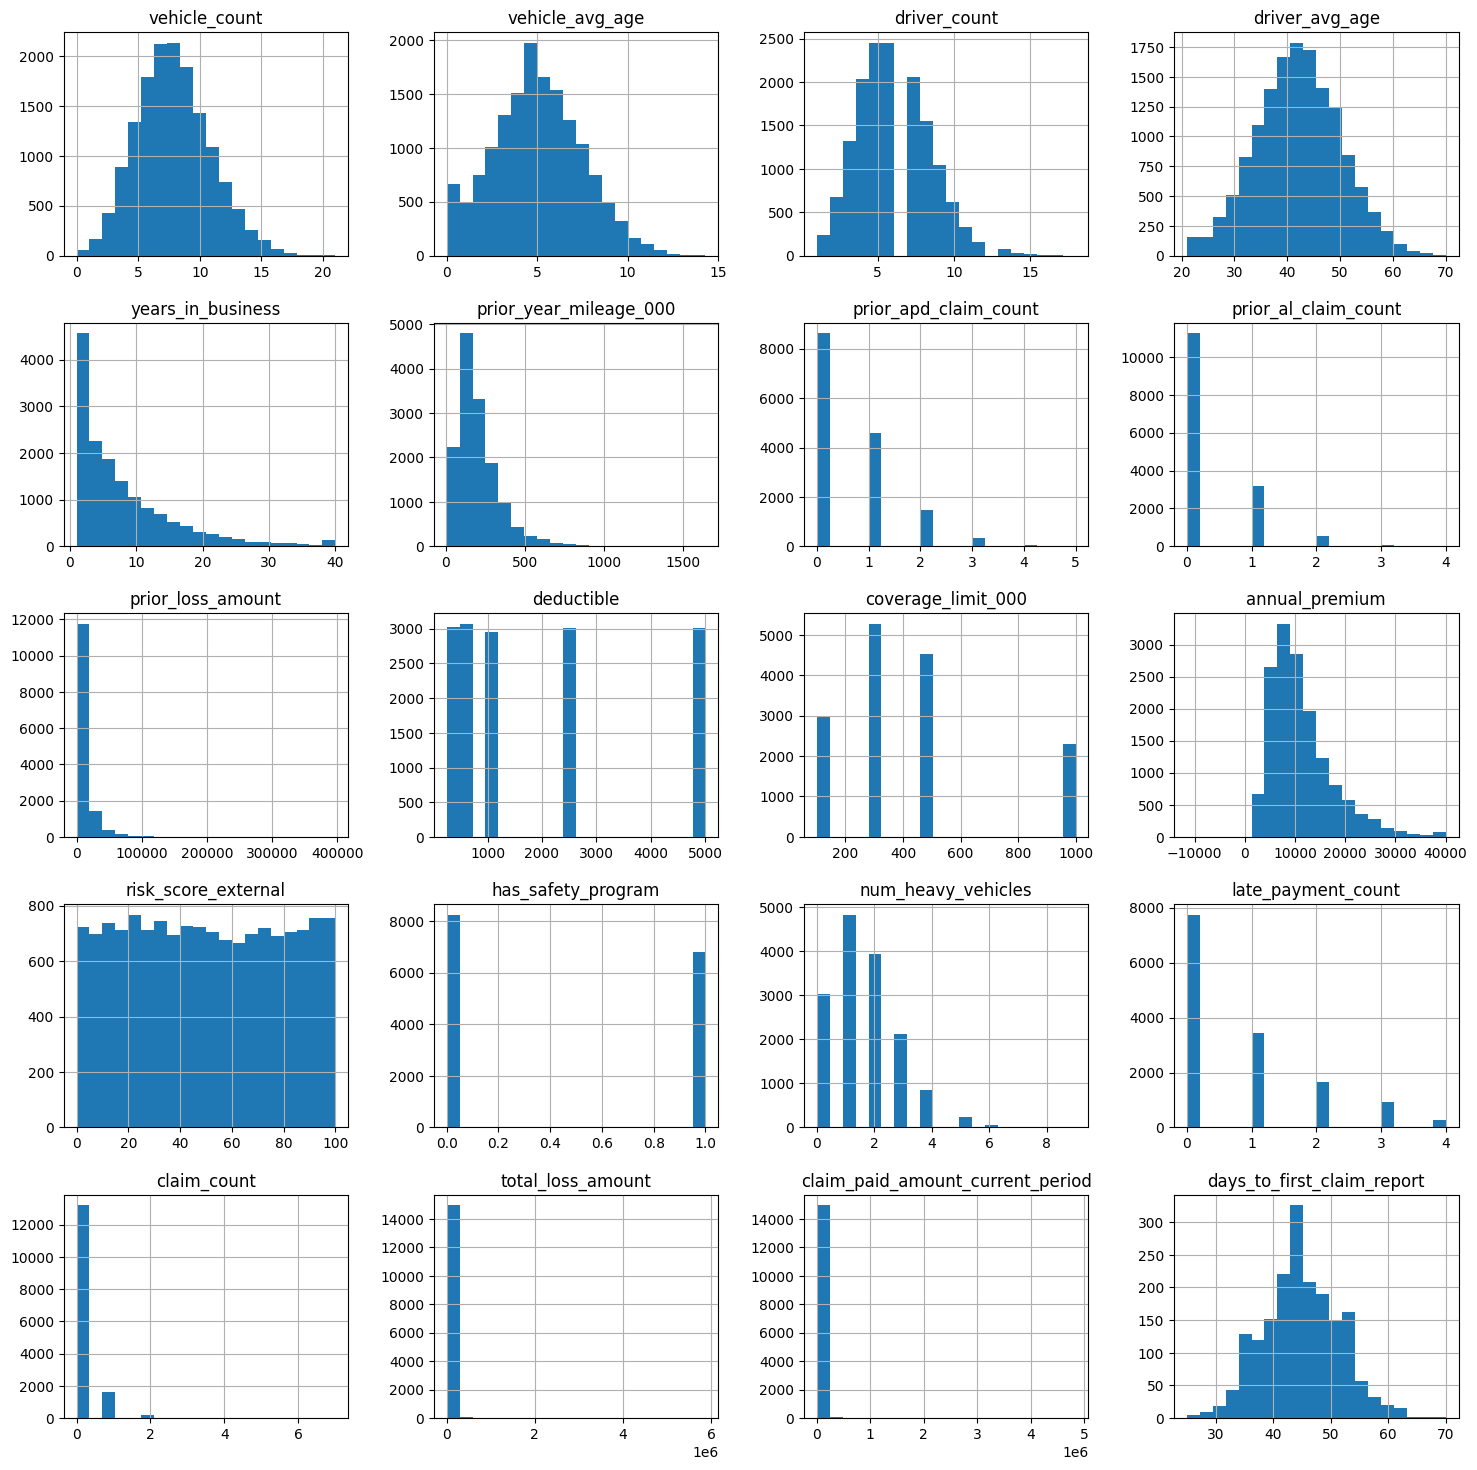

In [17]:
df2.hist(figsize=(18, 18), bins=20)


In [18]:
for col in df2.select_dtypes(include='number').columns:
    data = df2[col].dropna()
    stat, p = normaltest(data)
    print(f"{col}: {p} -> {'normal' if p > 0.05 else 'not normal'},\n {data.skew()} skew,\n {data.kurt()} kurtosis\n")

vehicle_count: 4.5687701924095374e-61 -> not normal,
 0.33840793837814914 skew,
 0.09259953666434706 kurtosis

vehicle_avg_age: 5.813246063040773e-19 -> not normal,
 0.1307115349695597 skew,
 -0.2274477655913385 kurtosis

driver_count: 1.3821651796038335e-98 -> not normal,
 0.4325919878250188 skew,
 0.18623294401946744 kurtosis

driver_avg_age: 0.015434427985042024 -> not normal,
 0.02862192564618048 skew,
 -0.09836563172067825 kurtosis

years_in_business: 0.0 -> not normal,
 1.697502490418694 skew,
 3.136313437093359 kurtosis

prior_year_mileage_000: 0.0 -> not normal,
 1.8979607088342292 skew,
 6.235931429383264 kurtosis

prior_apd_claim_count: 0.0 -> not normal,
 1.465508772818131 skew,
 2.323656638823217 kurtosis

prior_al_claim_count: 0.0 -> not normal,
 1.939611508409603 skew,
 3.913381010352202 kurtosis

prior_loss_amount: 0.0 -> not normal,
 5.4347025076686775 skew,
 58.76302630139121 kurtosis

deductible: 0.0 -> not normal,
 0.9004404620492034 skew,
 -0.7099042986392035 kurtos

We are right to use LogisticRegression as it appears our data is not normally distributed.

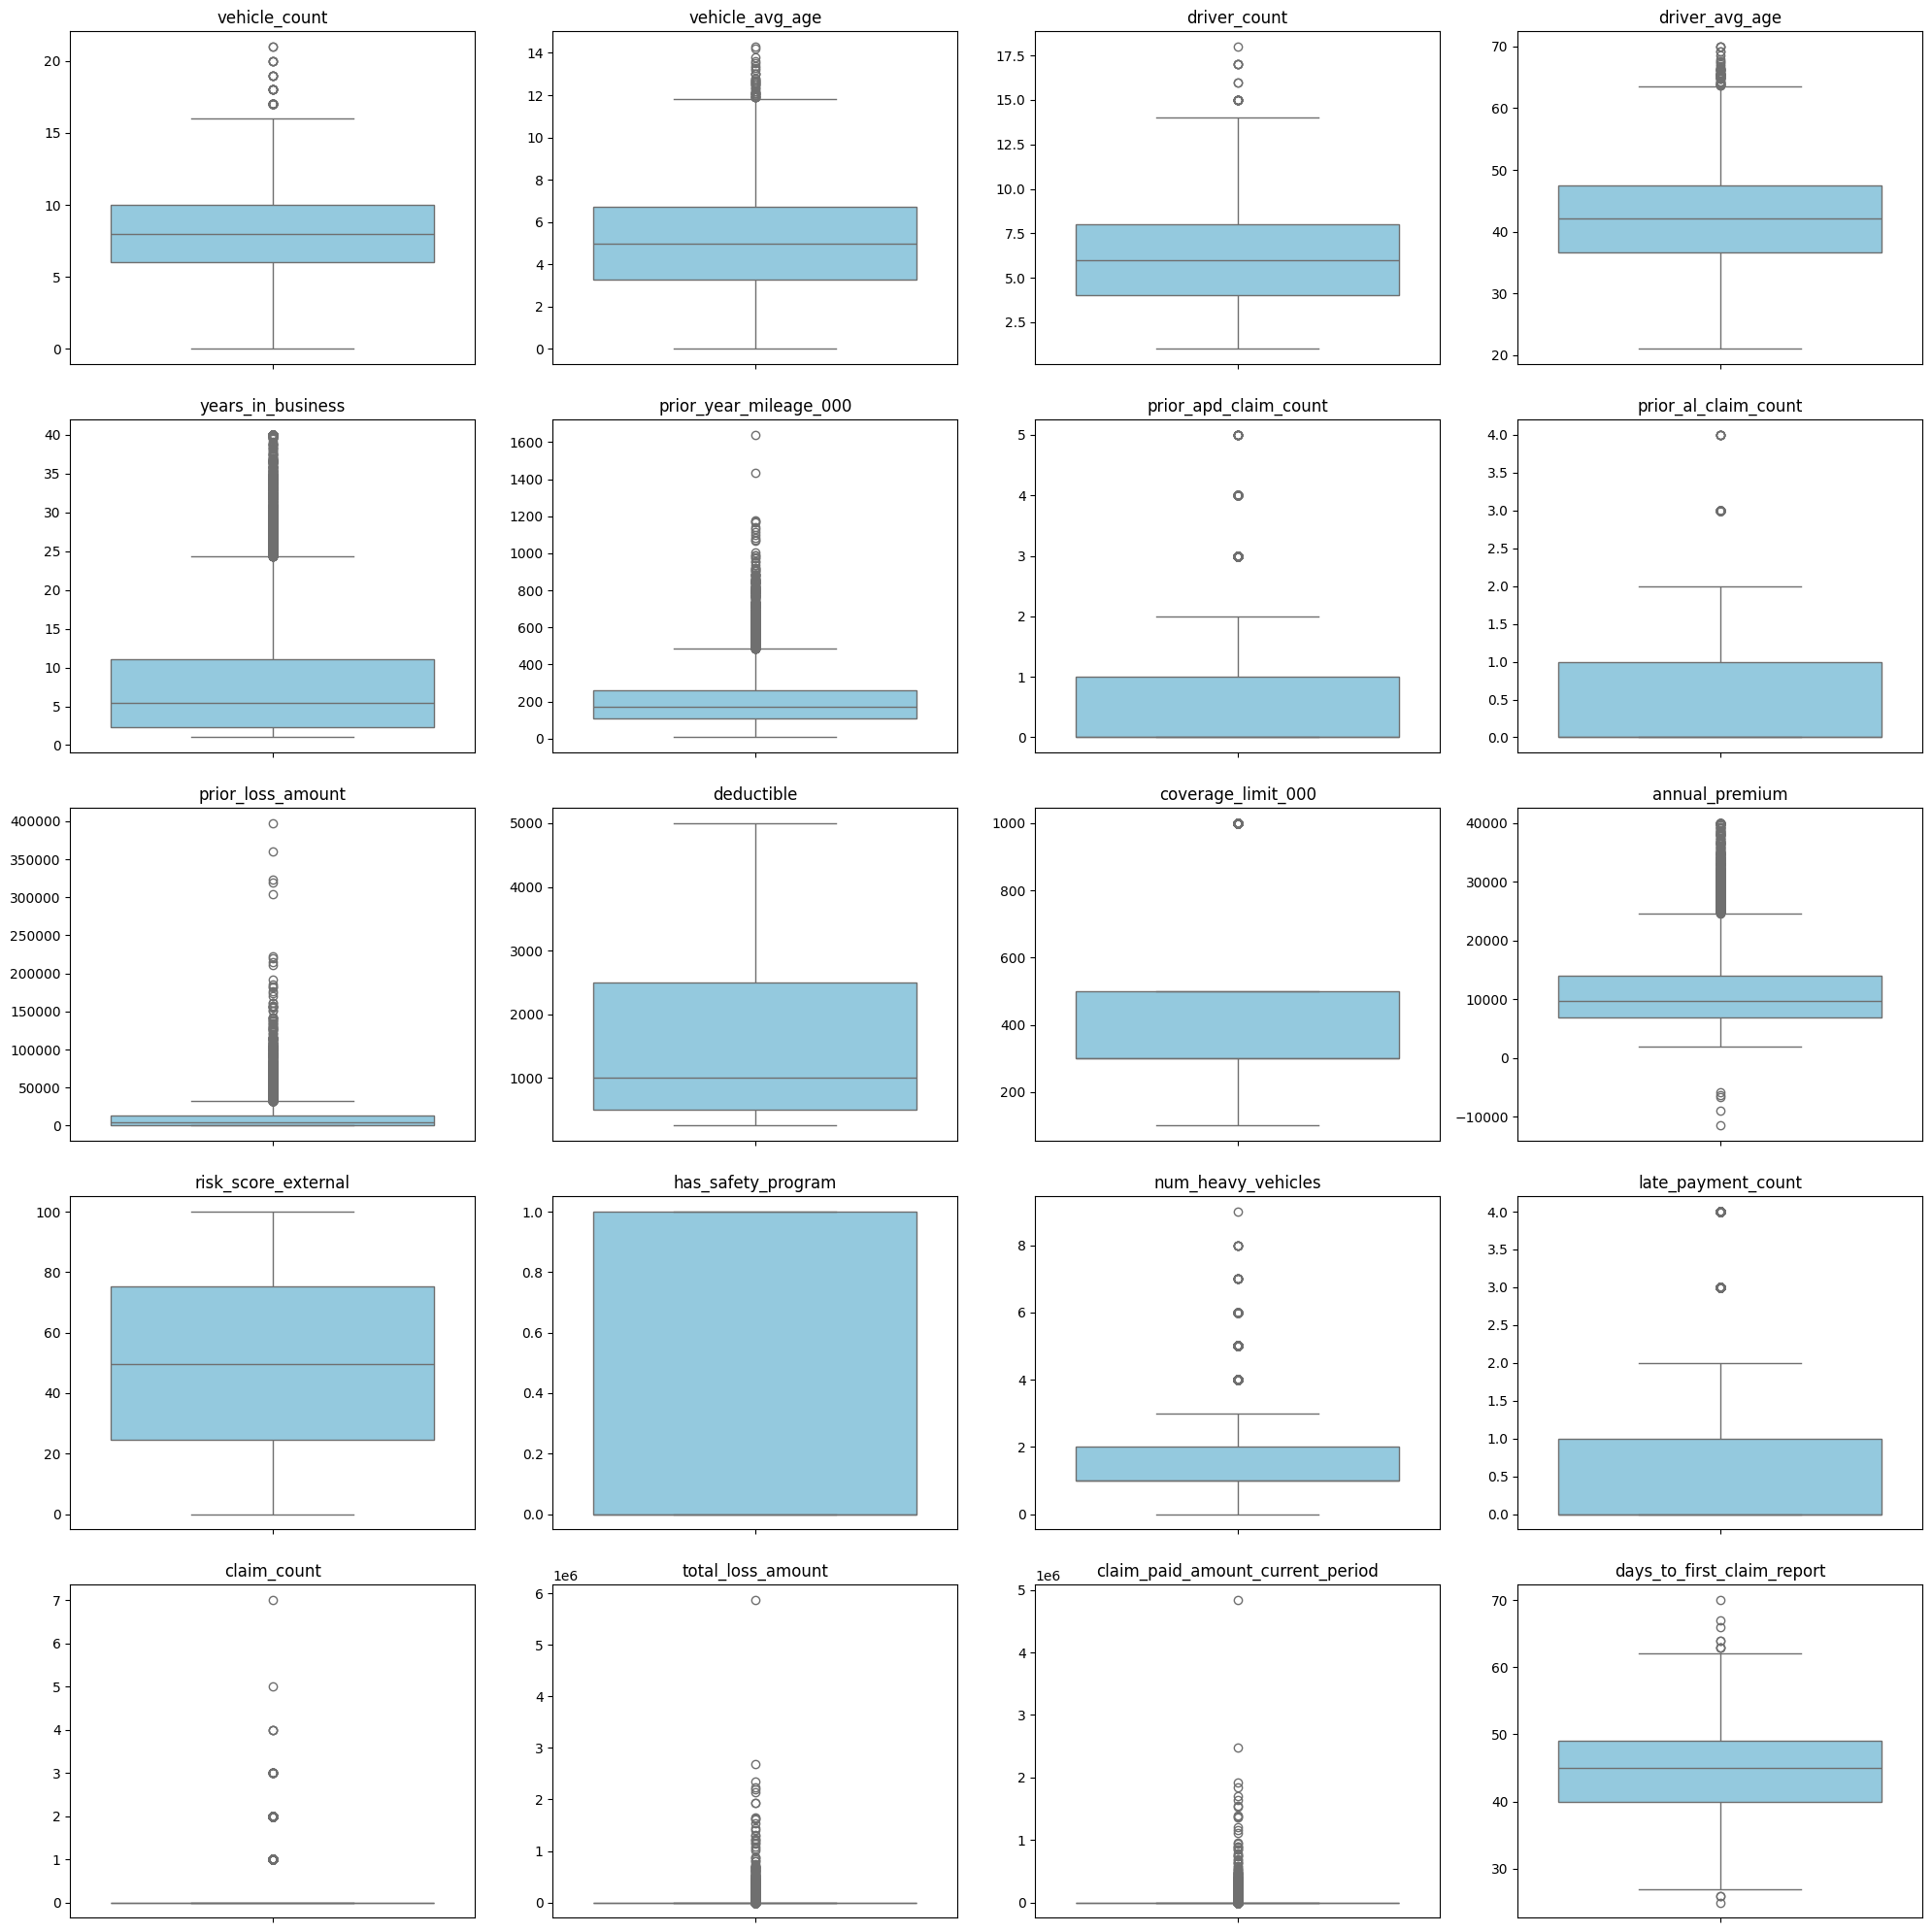

In [19]:
#Just for numerical columns (int and float) from df2
numeric_cols = df2.select_dtypes(include=['int64', 'float64']).columns

num_cols = 4
num_rows = (len(numeric_cols) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df2, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('')

#Hide unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

We can see that almost all of our columns from the train dataframe have outliers, which we will have to alter or drop to make predictions of the model more precise.

# Relationships and Correlations

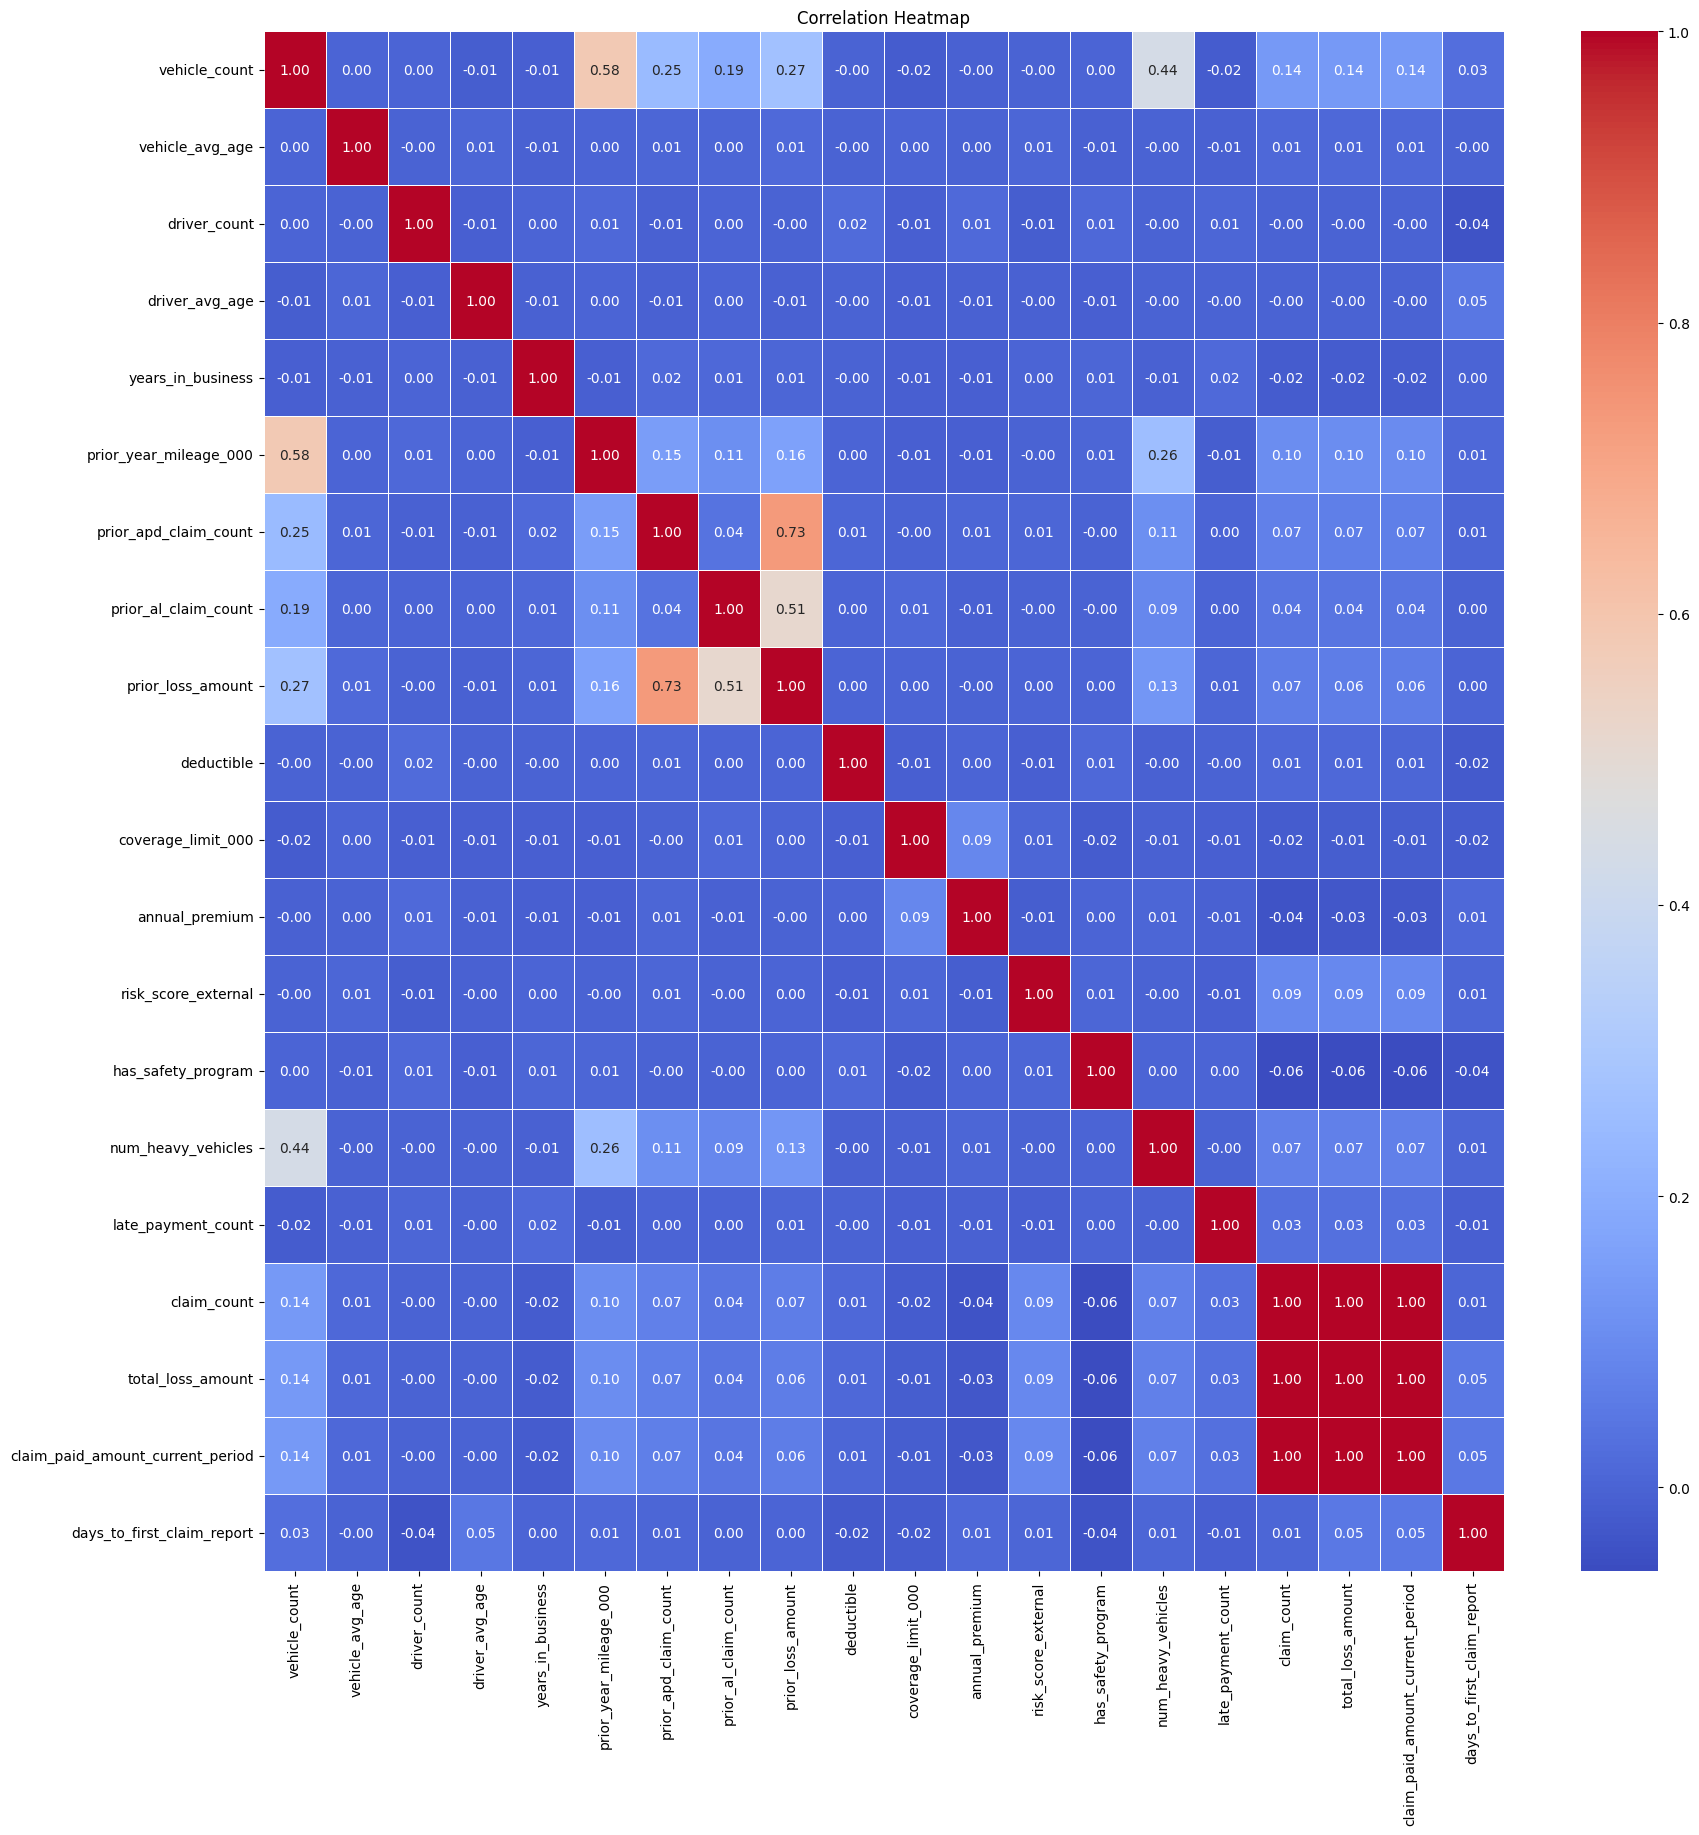

In [20]:
corr = df2.select_dtypes(include=['int64', 'float64']).corr(method='spearman')

plt.figure(figsize=(20, 20))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

The resulting heatmap highlights attributes that are most related to each other or the targets: claim_count, total_loss_amount, has_safety_program. We can safely assume which variables may be redundant or highly correlated. Spearman method was neccessary to use because the data we are working with is not normally distributed.

Found 13 pairs with correlation > 0.15


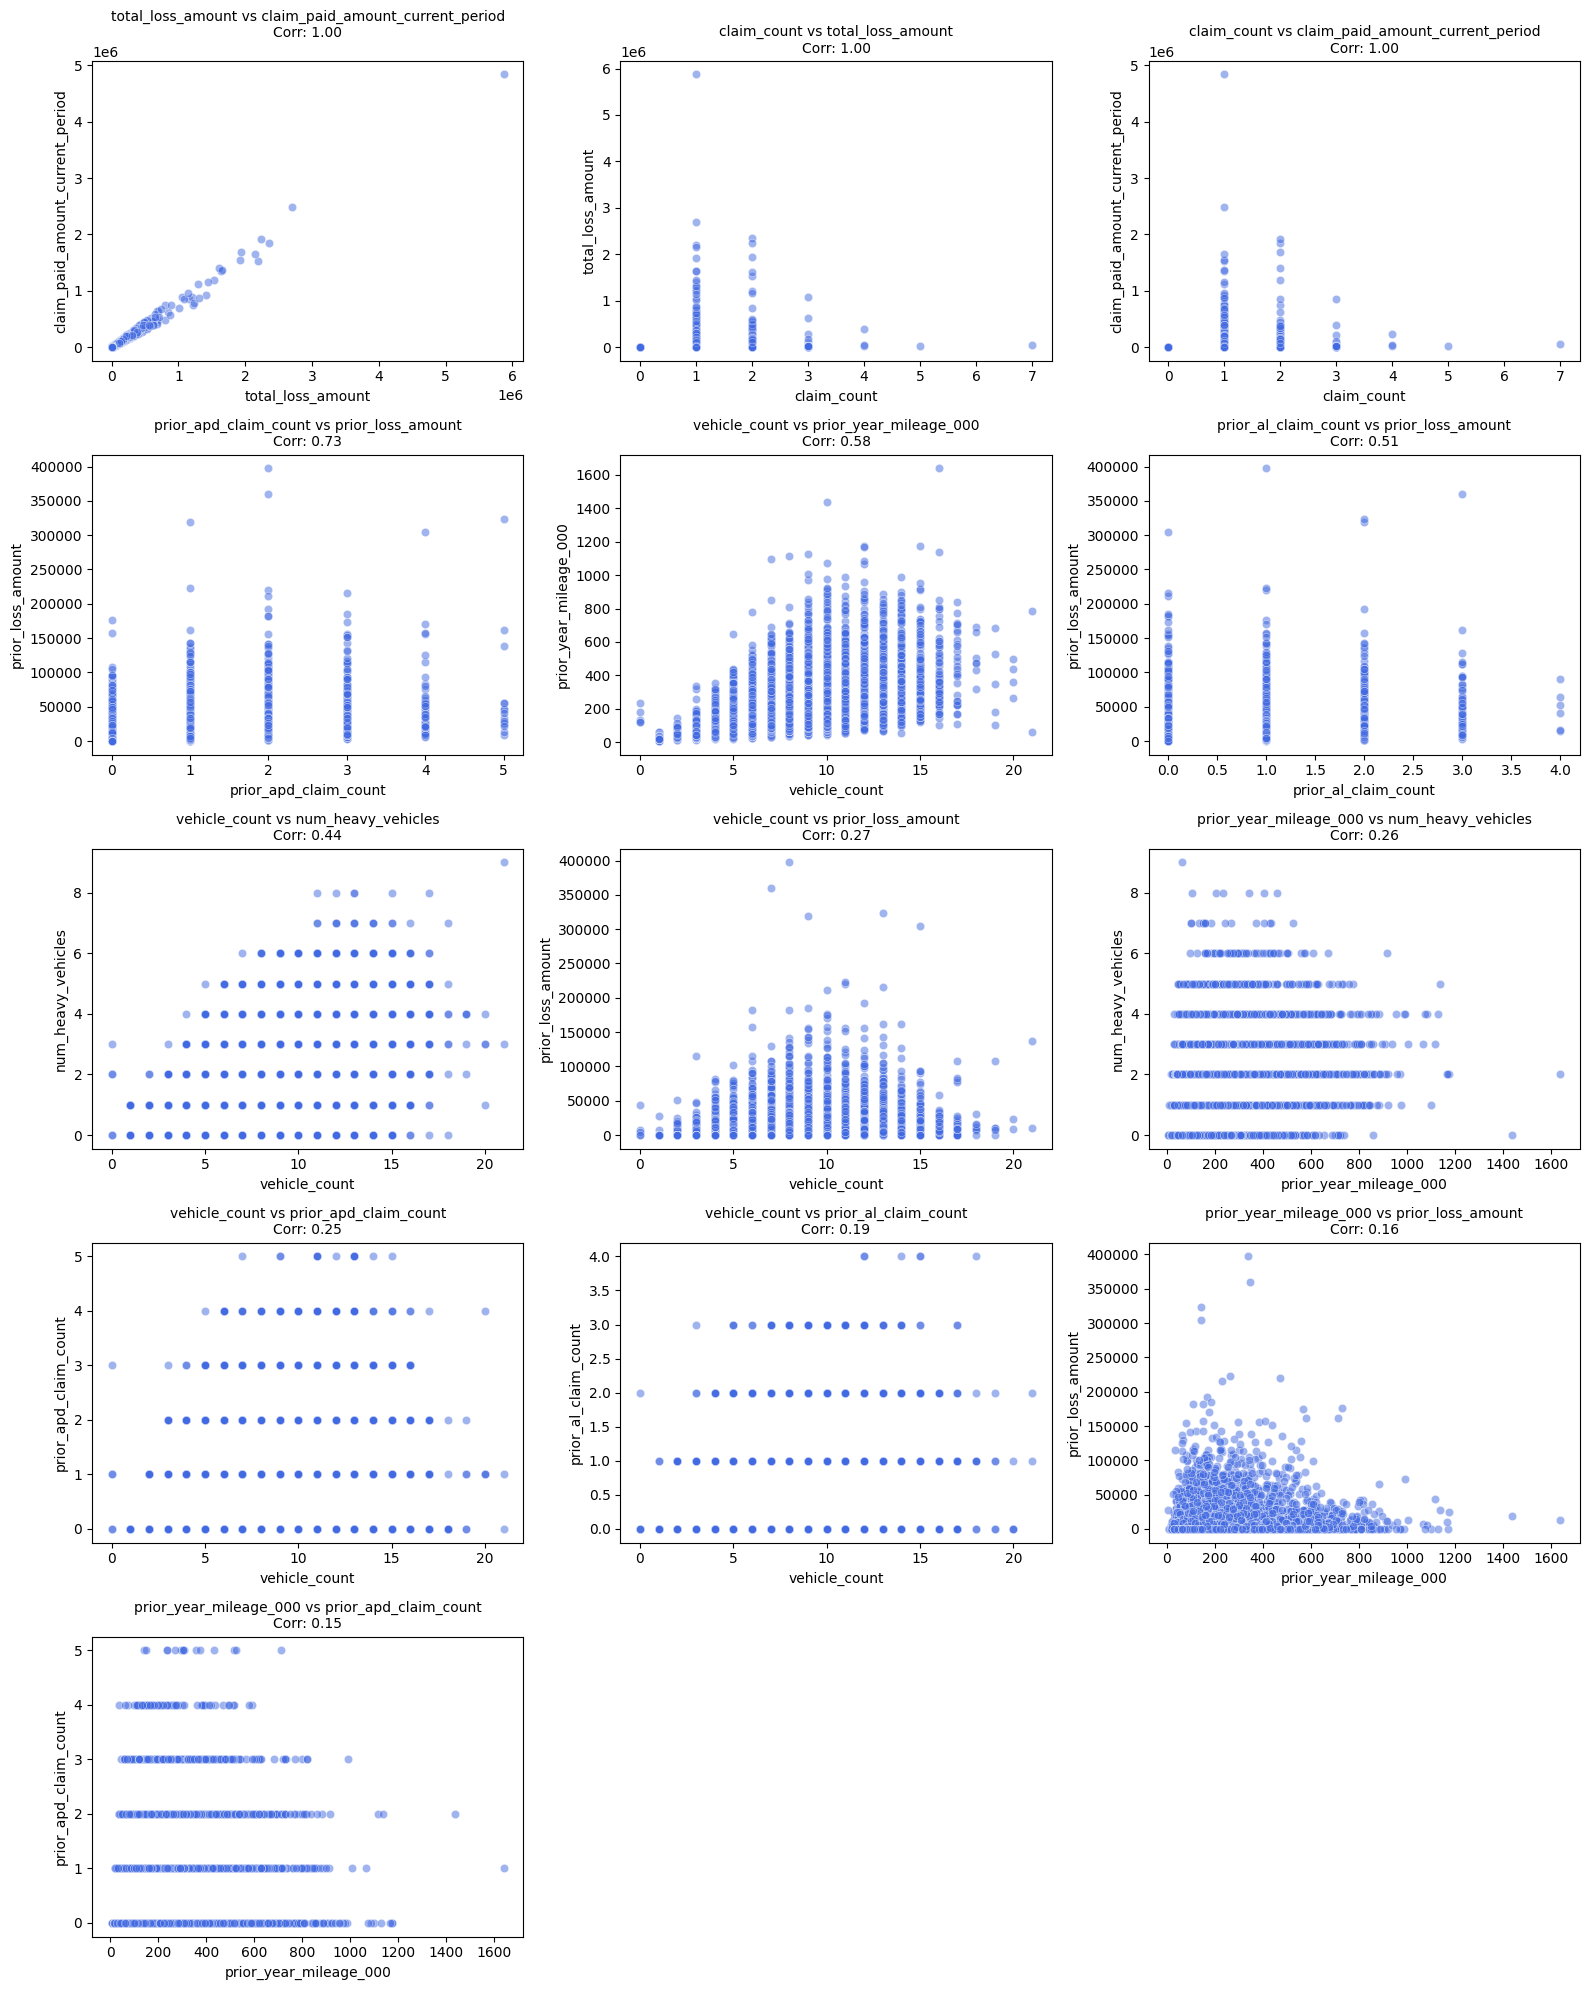

In [21]:

#Compute Spearman correlation matrix - not using normal distributed data
corr_matrix = df2.select_dtypes(include=['int64', 'float64']).corr(method='spearman')

corr_unstacked = corr_matrix.unstack().reset_index()
corr_unstacked.columns = ['feature1', 'feature2', 'correlation']

#Filter out self-correlations and keep only abs(corr) > 0.20
threshold = 0.15
filtered_pairs = corr_unstacked[
    (corr_unstacked['feature1'] != corr_unstacked['feature2']) &
    (corr_unstacked['correlation'].abs() > threshold)
].copy()

#Remove duplicate pairs
filtered_pairs['sorted_pair'] = filtered_pairs.apply(lambda row: tuple(sorted([row['feature1'], row['feature2']])), axis=1)
filtered_pairs = filtered_pairs.drop_duplicates(subset=['sorted_pair']).drop(columns=['sorted_pair'])

#Sort
filtered_pairs = filtered_pairs.reindex(filtered_pairs['correlation'].abs().sort_values(ascending=False).index).reset_index(drop=True)

print(f"Found {len(filtered_pairs)} pairs with correlation > {threshold}")

num_pairs = len(filtered_pairs)
if num_pairs > 0:
    num_cols = 3
    num_rows = (num_pairs + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, num_rows * 4))
    axes = axes.flatten()

    for i, row in filtered_pairs.iterrows():
        f1 = row['feature1']
        f2 = row['feature2']
        c_val = row['correlation']

        sns.scatterplot(data=df2, x=f1, y=f2, ax=axes[i], alpha=0.5, color='royalblue')
        axes[i].set_title(f"{f1} vs {f2}\nCorr: {c_val:.2f}", fontsize=10)

    #Hide unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

Our label attributes - total_loss_amount and claim_count - have 100% correlation in between them, but that makes sense since they both serve as expected results. However, what seems troubling is 100% correlation in between both target variables and claim_paid_amount_current_period value. Later on, this variable will definitely have to be dropped. Other than that, we can see a big impact of outliers, which we have showcased before, and will have to deal with in later steps.

In [22]:
# Get correlation of all numeric features against a target feat
target_name = 'total_loss_amount'
corrs = df2.select_dtypes(include=['int64', 'float64']).corr(method='spearman')[target_name]
print(corrs.sort_values(ascending=False))

total_loss_amount                   1.000000
claim_paid_amount_current_period    0.999980
claim_count                         0.996697
vehicle_count                       0.139610
prior_year_mileage_000              0.103503
risk_score_external                 0.091115
num_heavy_vehicles                  0.073472
prior_apd_claim_count               0.068255
prior_loss_amount                   0.064702
days_to_first_claim_report          0.051898
prior_al_claim_count                0.043514
late_payment_count                  0.030426
vehicle_avg_age                     0.010223
deductible                          0.008468
driver_count                       -0.000749
driver_avg_age                     -0.000909
coverage_limit_000                 -0.013437
years_in_business                  -0.019648
annual_premium                     -0.032523
has_safety_program                 -0.056807
Name: total_loss_amount, dtype: float64


In [23]:
target_name = 'claim_count'
corrs = df2.select_dtypes(include=['int64', 'float64']).corr(method='spearman')[target_name]
print(corrs.sort_values(ascending=False))

claim_count                         1.000000
total_loss_amount                   0.996697
claim_paid_amount_current_period    0.996695
vehicle_count                       0.140655
prior_year_mileage_000              0.104737
risk_score_external                 0.091335
num_heavy_vehicles                  0.071521
prior_apd_claim_count               0.070569
prior_loss_amount                   0.065651
prior_al_claim_count                0.042397
late_payment_count                  0.030256
vehicle_avg_age                     0.011360
deductible                          0.008881
days_to_first_claim_report          0.005328
driver_count                       -0.000631
driver_avg_age                     -0.000936
years_in_business                  -0.018940
coverage_limit_000                 -0.020006
annual_premium                     -0.040671
has_safety_program                 -0.057636
Name: claim_count, dtype: float64


**Data cleaning and preprocessing**

In [24]:
#Creating a copy of train dataframe
df2_clean = df2.copy()

print(f"Original row count: {len(df2_clean)}")
df2_clean = df2_clean.drop_duplicates()
print(f"Row count after dropping exact duplicates: {len(df2_clean)}")

df2_clean.info()

Original row count: 15075
Row count after dropping exact duplicates: 15033
<class 'pandas.core.frame.DataFrame'>
Index: 15033 entries, 0 to 15074
Data columns (total 31 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         15033 non-null  object 
 1   insured_id                        15033 non-null  object 
 2   snapshot_date                     15033 non-null  object 
 3   policy_effective_date             15033 non-null  object 
 4   policy_expiration_date            15033 non-null  object 
 5   coverage_type                     15033 non-null  object 
 6   vehicle_count                     15033 non-null  int64  
 7   vehicle_avg_age                   15033 non-null  float64
 8   driver_count                      15033 non-null  int64  
 9   driver_avg_age                    14431 non-null  float64
 10  years_in_business                 15033 non-null  float64
 1

In [25]:
#target_col = 'total_loss_amount'
target_col = 'claim_count'

has_date = df2_clean['first_claim_reported_date'].notnull()
labels_are_zero_when_no_date = (df2_clean.loc[~has_date, target_col] == 0).all()
print(f"1) When 'first_claim_reported_date' is NULL, are all labels 0? {labels_are_zero_when_no_date}")

is_no_claim = df2_clean['claim_status_current_period'] == 'No Claim'
labels_are_zero_when_no_claim = (df2_clean.loc[is_no_claim, target_col] == 0).all()
print(f"2) When status is 'No Claim', are all labels 0? {labels_are_zero_when_no_claim}")

has_days = df2_clean['days_to_first_claim_report'].notnull()
labels_are_zero_when_no_days = (df2_clean.loc[~has_days, target_col] == 0).all()
print(f"3) When 'days_to_first_claim_report' is NULL, are all labels 0? {labels_are_zero_when_no_days}")

1) When 'first_claim_reported_date' is NULL, are all labels 0? True
2) When status is 'No Claim', are all labels 0? True
3) When 'days_to_first_claim_report' is NULL, are all labels 0? True


This test cofirms my observation, and thats that when there is date present, other claim_status then No Claim and any number in column days_to_first_claim_report, we are guaranteed to recieve label values other then 1. This represnents data leak. In next step we drop these columns from df2 aswell as df3 table.

In [26]:

df3_clean = df3.copy()

columns_to_drop = [
    'claim_paid_amount_current_period',
    'first_claim_reported_date',
    'claim_status_current_period',
    'days_to_first_claim_report'
]

df2_clean = df2_clean.drop(columns=columns_to_drop, errors='ignore')
df3_clean = df3_clean.drop(columns=columns_to_drop, errors='ignore')

df2_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15033 entries, 0 to 15074
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   policy_id               15033 non-null  object 
 1   insured_id              15033 non-null  object 
 2   snapshot_date           15033 non-null  object 
 3   policy_effective_date   15033 non-null  object 
 4   policy_expiration_date  15033 non-null  object 
 5   coverage_type           15033 non-null  object 
 6   vehicle_count           15033 non-null  int64  
 7   vehicle_avg_age         15033 non-null  float64
 8   driver_count            15033 non-null  int64  
 9   driver_avg_age          14431 non-null  float64
 10  years_in_business       15033 non-null  float64
 11  prior_year_mileage_000  14133 non-null  float64
 12  business_type           15033 non-null  object 
 13  state                   15033 non-null  object 
 14  prior_apd_claim_count   15033 non-null  int

In [27]:
df3_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   policy_id               3000 non-null   object 
 1   insured_id              3000 non-null   object 
 2   snapshot_date           3000 non-null   object 
 3   policy_effective_date   3000 non-null   object 
 4   policy_expiration_date  3000 non-null   object 
 5   coverage_type           3000 non-null   object 
 6   vehicle_count           3000 non-null   int64  
 7   vehicle_avg_age         3000 non-null   float64
 8   driver_count            3000 non-null   int64  
 9   driver_avg_age          2880 non-null   float64
 10  years_in_business       3000 non-null   float64
 11  prior_year_mileage_000  2820 non-null   float64
 12  business_type           3000 non-null   object 
 13  state                   3000 non-null   object 
 14  prior_apd_claim_count   3000 non-null   

In [28]:
df2_clean.isnull().sum()

,0
policy_id,0
insured_id,0
snapshot_date,0
policy_effective_date,0
policy_expiration_date,0
coverage_type,0
vehicle_count,0
vehicle_avg_age,0
driver_count,0
driver_avg_age,602


In [29]:
df3_clean.isnull().sum()

,0
policy_id,0
insured_id,0
snapshot_date,0
policy_effective_date,0
policy_expiration_date,0
coverage_type,0
vehicle_count,0
vehicle_avg_age,0
driver_count,0
driver_avg_age,120


In [30]:
cols_to_impute_numeric = [
    'driver_avg_age',
    'prior_year_mileage_000',
    'prior_loss_amount',
    'risk_score_external',
    'late_payment_count'
]

#1.Compute the MEDIANS just from the training dataset (df2_clean)
medians = df2_clean[cols_to_impute_numeric].median()

#2.Use on BOTH df2_clean and df3_clean
df2_clean[cols_to_impute_numeric] = df2_clean[cols_to_impute_numeric].fillna(medians)
df3_clean[cols_to_impute_numeric] = df3_clean[cols_to_impute_numeric].fillna(medians)


We have replaced Null values in numeric columns with median values of the columns inside the training (DF2) dataframe.

In [31]:
#Count frequency of every payment frequency type
frequency_counts = df2_clean['payment_frequency'].value_counts(dropna=False)
print(frequency_counts)

payment_frequency
Annual       5199
Monthly      5015
Quarterly    4368
NaN           451
Name: count, dtype: int64


Data is distributed among 3 classes, we could try to assign values to missing records randomly, or use more complicated way and try to predict them, but in this case i chose to create new "Unknow" class just for them.

In [32]:
df2_clean['payment_frequency'] = df2_clean['payment_frequency'].fillna('Unknown')
df3_clean['payment_frequency'] = df3_clean['payment_frequency'].fillna('Unknown')

we officially have no null values among our dataframes

Here we return to resolve the issue with "partial" duplicates. It turns out it was just a case of incorrectly written names of the classes in the business_type attribute—starting with lowercase or uppercase. Simply rewriting them to the same form should resolve this issue. This approach we should use for all categorical data, but in this case, only this column suffers this problem, so it is not necessary. In a more advanced pipeline, a schema would resolve this problem.

In [33]:
#Convert 'business_type' to lowercase in both df2_clean and df3_clean
df2_clean['business_type'] = df2_clean['business_type'].str.lower()
df3_clean['business_type'] = df3_clean['business_type'].str.lower()

#unique categories after lowercasing
print("Unique business types in df2_clean:")
print(df2_clean['business_type'].unique())

Unique business types in df2_clean:
['service' 'trucking' 'construction' 'retail' 'other' 'agriculture']


In [34]:
df2_clean = df2_clean.drop_duplicates()

In [35]:
df2_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 15074
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   policy_id               15000 non-null  object 
 1   insured_id              15000 non-null  object 
 2   snapshot_date           15000 non-null  object 
 3   policy_effective_date   15000 non-null  object 
 4   policy_expiration_date  15000 non-null  object 
 5   coverage_type           15000 non-null  object 
 6   vehicle_count           15000 non-null  int64  
 7   vehicle_avg_age         15000 non-null  float64
 8   driver_count            15000 non-null  int64  
 9   driver_avg_age          15000 non-null  float64
 10  years_in_business       15000 non-null  float64
 11  prior_year_mileage_000  15000 non-null  float64
 12  business_type           15000 non-null  object 
 13  state                   15000 non-null  object 
 14  prior_apd_claim_count   15000 non-null  int

In [36]:
df2_clean.nunique()

,0
policy_id,15000
insured_id,3702
snapshot_date,1095
policy_effective_date,1248
policy_expiration_date,1250
coverage_type,2
vehicle_count,22
vehicle_avg_age,138
driver_count,18
driver_avg_age,452


our df2 finally has just 15000 records, all with unique policy_id.

In [44]:
def process_dates(df):
    #Check if original date columns exist before
    if 'policy_effective_date' not in df.columns or 'snapshot_date' not in df.columns:
        print("Raw date columns not found. Skipping date processing (already processed or dropped).")
        return df

    df['policy_effective_date'] = pd.to_datetime(df['policy_effective_date'])
    df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])

    #Engineer Policy Duration in days
    df['policy_duration_days'] = (df['snapshot_date'] - df['policy_effective_date']).dt.days

    #Extract Year and Month
    df['effective_year'] = df['policy_effective_date'].dt.year
    df['effective_month'] = df['policy_effective_date'].dt.month

    #Bucket Months into Seasons
    def map_season(month):
        if month in [12, 1, 2]:
            return 'winter'
        elif month in [3, 4, 5]:
            return 'spring'
        elif month in [6, 7, 8]:
            return 'summer'
        else:
            return 'autumn'

    df['effective_season'] = df['effective_month'].apply(map_season)

    #Drop old raw date columns
    df = df.drop(columns=['policy_effective_date', 'snapshot_date', 'policy_expiration_date'], errors='ignore')

    return df

#Apply the function to both dataframes
df2_clean = process_dates(df2_clean)
df3_clean = process_dates(df3_clean)

print("Date engineering complete!")
if 'policy_duration_days' in df2_clean.columns:
    print("df2_clean new columns check:", df2_clean[['policy_duration_days', 'effective_year', 'effective_season']].head(2))
else:
    print("df2_clean check: Columns were already created and might have been processed/dropped further down the line.")

Raw date columns not found. Skipping date processing (already processed or dropped).
Raw date columns not found. Skipping date processing (already processed or dropped).
Date engineering complete!
df2_clean new columns check:    policy_duration_days  effective_year effective_season
0                    59            2021           spring
1                   111            2020           autumn


In [45]:
df2_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 15074
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   policy_id               15000 non-null  object 
 1   insured_id              15000 non-null  object 
 2   coverage_type           15000 non-null  object 
 3   vehicle_count           15000 non-null  int64  
 4   vehicle_avg_age         15000 non-null  float64
 5   driver_count            15000 non-null  int64  
 6   driver_avg_age          15000 non-null  float64
 7   years_in_business       15000 non-null  float64
 8   prior_year_mileage_000  15000 non-null  float64
 9   business_type           15000 non-null  object 
 10  state                   15000 non-null  object 
 11  prior_apd_claim_count   15000 non-null  int64  
 12  prior_al_claim_count    15000 non-null  int64  
 13  prior_loss_amount       15000 non-null  float64
 14  deductible              15000 non-null  int

We check if newly encoded and Derived columns, have high correlation with our label "target" attributes.

In [46]:
target_col = 'total_loss_amount'

#new numerical features + the target
features_to_check = ['policy_duration_days', 'effective_year', 'effective_month', target_col]

#Spearman Correlation
spearman_corr = df2_clean[features_to_check].corr(method='spearman')[target_col].sort_values(ascending=False)

print(spearman_corr)

total_loss_amount       1.000000
effective_month         0.005695
effective_year          0.004723
policy_duration_days   -0.007870
Name: total_loss_amount, dtype: float64


They don't appear to have any significant influence, so we drop them (effective_month can be kept for dataframe splitting purposes).

In [47]:
columns_to_drop = [
    'effective_month',
    'effective_season',
    'policy_duration_days'
]

df2_clean = df2_clean.drop(columns=columns_to_drop, errors='ignore')
df3_clean = df3_clean.drop(columns=columns_to_drop, errors='ignore')

df3_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   policy_id               3000 non-null   object 
 1   insured_id              3000 non-null   object 
 2   coverage_type           3000 non-null   object 
 3   vehicle_count           3000 non-null   int64  
 4   vehicle_avg_age         3000 non-null   float64
 5   driver_count            3000 non-null   int64  
 6   driver_avg_age          3000 non-null   float64
 7   years_in_business       3000 non-null   float64
 8   prior_year_mileage_000  3000 non-null   float64
 9   business_type           3000 non-null   object 
 10  state                   3000 non-null   object 
 11  prior_apd_claim_count   3000 non-null   int64  
 12  prior_al_claim_count    3000 non-null   int64  
 13  prior_loss_amount       3000 non-null   float64
 14  deductible              3000 non-null   

In [48]:
df2_clean.nunique()

,0
policy_id,15000
insured_id,3702
coverage_type,2
vehicle_count,22
vehicle_avg_age,138
driver_count,18
driver_avg_age,452
years_in_business,374
prior_year_mileage_000,4326
business_type,6


In [49]:
df3_clean.nunique()

,0
policy_id,3000
insured_id,739
coverage_type,2
vehicle_count,20
vehicle_avg_age,121
driver_count,16
driver_avg_age,376
years_in_business,320
prior_year_mileage_000,2030
business_type,6


Spotting the imbalance problem with our label column. The majority of records (13,000/15,000) are No Claim records. This is very dangerous because just by the model predicting everything as No Claim, he could receive a high accuracy rating. The model needs to value "Claim" more than "No Claim".

In [50]:
zero_claims_count = (df2_clean['claim_count'] == 0).sum()
print(f"Number of records with 0 claims: {zero_claims_count}")

Number of records with 0 claims: 13146


In [52]:
categorical_cols = ['coverage_type', 'business_type', 'payment_frequency', 'effective_season', 'state']

existing_cols_df2 = [col for col in categorical_cols if col in df2_clean.columns]
df2_clean = pd.get_dummies(df2_clean, columns=existing_cols_df2, dtype=int)

existing_cols_df3 = [col for col in categorical_cols if col in df3_clean.columns]
df3_clean = pd.get_dummies(df3_clean, columns=existing_cols_df3, dtype=int)

#Align columns to ensure train and test sets have the exact same structure
df2_clean, df3_clean = df2_clean.align(df3_clean, join='left', axis=1, fill_value=0)

print(f"df2_clean shape after encoding all categoricals: {df2_clean.shape}")
print(f"df3_clean shape after encoding all categoricals: {df3_clean.shape}")

df2_clean shape after encoding all categoricals: (15000, 45)
df3_clean shape after encoding all categoricals: (3000, 45)


Here we encode every single value of several categorical columns, so we have all numeric columns that our Logistic Regression classifier can understand.

In [53]:
target_col = 'claim_count'

#Filter for columns that start with 'state_'
state_cols = [col for col in df2_clean.columns if col.startswith('state_')]

temp_state_df = pd.concat([df2_clean[state_cols], df2_clean[target_col]], axis=1)

#Compute Spearman correlation against the target
state_corr = temp_state_df.corr(method='spearman')[target_col].drop(target_col).sort_values(ascending=False)

print("Spearman Correlation of States with Label column:")
print(state_corr)

Spearman Correlation of States with Label column:
state_TX    0.011844
state_PA    0.009930
state_NC    0.008420
state_CA    0.006766
state_FL    0.006269
state_CO   -0.001871
state_NY   -0.002074
state_IL   -0.005254
state_OH   -0.006294
state_WA   -0.006403
state_AZ   -0.009799
state_GA   -0.013439
Name: claim_count, dtype: float64


State does appear to be valid feature to use for classification.

In [54]:
#Claim count becomes binary - yes/no
y = (df2_clean['claim_count'] > 0).astype(int)

#Save policy_ids aside for tracking
train_policy_ids = df2_clean['policy_id'].copy()
test_policy_ids = df3_clean['policy_id'].copy()

#Frequency encode 'insured_id' -> ids would confuse the models - takes them as values
insured_counts = df2_clean['insured_id'].value_counts()
df2_clean['insured_frequency'] = df2_clean['insured_id'].map(insured_counts).fillna(1)
df3_clean['insured_frequency'] = df3_clean['insured_id'].map(insured_counts).fillna(1)

#Drop IDs AND the original label columns from your feature matrix (X)
drop_cols = ['policy_id', 'insured_id', 'claim_count', 'total_loss_amount']
X = df2_clean.drop(columns=drop_cols, errors='ignore')

print(f"Features shape (X): {X.shape}")
print(f"Target shape (y): {y.shape}")
print(f"Target positive rate: {y.mean():.3f}")

Features shape (X): (15000, 42)
Target shape (y): (15000,)
Target positive rate: 0.124


In [55]:
y.info()

<class 'pandas.core.series.Series'>
Index: 15000 entries, 0 to 15074
Series name: claim_count
Non-Null Count  Dtype
--------------  -----
15000 non-null  int64
dtypes: int64(1)
memory usage: 234.4 KB


here, my changes end.

# ---- old preprocessing ----

fill numeric missing with 0 -- good enough for now
df2[df2.select_dtypes("number").columns] = df2.select_dtypes("number").fillna(0)
df3[df3.select_dtypes("number").columns] = df3.select_dtypes("number").fillna(0)

encode categoricals for train
df2["coverage_type"] = df2["coverage_type"].astype("category").cat.codes
df2["business_type"]  = df2["business_type"].astype("category").cat.codes
df2["state"]          = df2["state"].astype("category").cat.codes

same for score
df3["coverage_type"] = df3["coverage_type"].astype("category").cat.codes
df3["business_type"]  = df3["business_type"].astype("category").cat.codes
df3["state"]          = df3["state"].astype("category").cat.codes

We wont use any of this code, blindly inserting 0s to all missing numeric data is not a correct choice, not even average would be ideal, beacsue of our skew in data, so just throwing data into 0 would drastically change the distribution. I think using median or mode is the best possible option.

In [ ]:
# ---- target ----
# using binary had-a-claim flag as target
df2["target"] = (df2["claim_count"] > 0).astype(int)
print("positive rate:", round(df2["target"].mean(), 3))

In [ ]:
# ---- features ----
feat_cols = [
    "coverage_type",
    "vehicle_count", "vehicle_avg_age", "driver_count", "driver_avg_age",
    "years_in_business", "prior_year_mileage_000",
    "business_type", "state",
    "prior_apd_claim_count", "prior_al_claim_count", "prior_loss_amount",
    "deductible", "coverage_limit_000", "annual_premium",
    "risk_score_external", "num_heavy_vehicles", "late_payment_count",
    "claim_paid_amount_current_period",
    "days_to_first_claim_report",
]

X = df2[feat_cols]
y = df2["target"]

In [ ]:
# ---- fit model ----

# random split -- not time-based
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

tmp = LogisticRegression(max_iter=1000)
tmp.fit(X_train, y_train)

In [ ]:
# ---- evaluate ----
x1 = tmp.predict(X_train)
print("accuracy:", accuracy_score(y_train, x1))
# results look solid

In [ ]:
# ---- score new policies ----
X2 = df3[feat_cols]
preds = tmp.predict(X2)

df3["risk_score"] = preds
df3[["policy_id", "risk_score"]].to_csv("predictions.csv")
print("done -- predictions.csv written")